In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [42]:
import pandas as pd

FOLDER_PATH = '/content/drive/MyDrive/Multilabel'
LABELS_FILE = '/content/drive/MyDrive/Multilabel/labels.txt'


df = pd.read_csv(LABELS_FILE, sep=None, engine='python')

print("--- Column Names Found ---")
print(df.columns.tolist())
print("\n--- First Row of Data ---")
print(df.iloc[0])

--- Column Names Found ---
['image_0.jpg', '1', 'NA', '0', '1.1']

--- First Row of Data ---
image_0.jpg    image_1.jpg
1                      NaN
NA                     0.0
0                      0.0
1.1                    0.0
Name: 0, dtype: object


In [43]:



LABELS_FILE = '/content/drive/MyDrive/Multilabel/labels.txt'


column_names = ['Image_Name', 'Attr1', 'Attr2', 'Attr3', 'Attr4']


df = pd.read_csv(LABELS_FILE, sep='\s+', header=None, names=column_names, engine='python')


def clean_label(value):
    value = str(value).strip().lower()
    if 'na' in value:
        return -1
    if '1' in value:
        return 1
    if '0' in value:
        return 0
    return -1


for col in ['Attr1', 'Attr2', 'Attr3', 'Attr4']:
    df[col] = df[col].apply(clean_label)

print("✅ Success! Data is now properly organized:")
print(df.head())

✅ Success! Data is now properly organized:
    Image_Name  Attr1  Attr2  Attr3  Attr4
0  image_0.jpg      1     -1      0      1
1  image_1.jpg     -1      0      0      0
2  image_2.jpg      1      1      0      0
3  image_3.jpg      1      1      0      0
4  image_4.jpg      1      1      0      0


<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-937732807.py:7: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(LABELS_FILE, sep='\s+', header=None, names=column_names, engine='python')


In [44]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

IMAGE_DIR = '/content/drive/MyDrive/Multilabel/images'


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class MultiLabelDataset(Dataset):
    def __init__(self, dataframe, image_directory, transform=None):
        self.df = dataframe
        self.image_directory = image_directory
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        img_name = self.df.iloc[idx]['Image_Name']
        img_path = os.path.join(self.image_directory, img_name)


        image = Image.open(img_path).convert('RGB')
        labels = self.df.iloc[idx][['Attr1', 'Attr2', 'Attr3', 'Attr4']].values.astype('float32')

        if self.transform:
            image = self.transform(image)

        return image, labels

train_dataset = MultiLabelDataset(df, IMAGE_DIR, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

images, labels = next(iter(train_loader))
print(f"Batch of images shape: {images.shape}")
print(f"Batch of labels shape: {labels.shape}")


Batch of images shape: torch.Size([8, 3, 224, 224])
Batch of labels shape: torch.Size([8, 4])


In [45]:
df.head()

,Image_Name,Attr1,Attr2,Attr3,Attr4
0,image_0.jpg,1,-1,0,1
1,image_1.jpg,-1,0,0,0
2,image_2.jpg,1,1,0,0
3,image_3.jpg,1,1,0,0
4,image_4.jpg,1,1,0,0


In [47]:
import torch
from torchvision import models
import torch.nn as nn

model = models.resnet50(pretrained=True)


num_features = model.fc.in_features

model.fc = nn.Linear(num_features, 4)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(" Complete: The Brain is ready and tuned for 4 attributes!")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


 Complete: The Brain is ready and tuned for 4 attributes!


In [48]:
import torch.nn as nn
import torch.optim as optim

def calculate_weights(dataframe):
    weights = []
    for col in ['Attr1', 'Attr2', 'Attr3', 'Attr4']:
        positives = (dataframe[col] == 1).sum()
        negatives = (dataframe[col] == 0).sum()
        # If there are few positives, weight goes UP
        weight = negatives / (positives + 1e-6)
        weights.append(weight)
    return torch.tensor(weights).to(device)

pos_weights = calculate_weights(df)


class MaskedBCEWithLogitsLoss(nn.Module):
    def __init__(self, weights):
        super().__init__()
        self.weights = weights

        self.loss_fn = nn.BCEWithLogitsLoss(pos_weight=self.weights, reduction='none')

    def forward(self, predictions, targets):

        mask = (targets != -1).float()
        clean_targets = torch.where(targets == -1, torch.zeros_like(targets), targets)
        loss = self.loss_fn(predictions, clean_targets)
        masked_loss = loss * mask


        return masked_loss.sum() / (mask.sum() + 1e-7)
criterion = MaskedBCEWithLogitsLoss(weights=pos_weights)
optimizer = optim.Adam(model.parameters(), lr=0.0001)


print(f"Calculated Weights for imbalance: {pos_weights.cpu().numpy()}")

Calculated Weights for imbalance: [ 0.13434727  0.2398317   0.89270386 11.95588218]


In [ ]:
import os
print(f"Rows before cleaning: {len(df)}")
df = df[df['Image_Name'].apply(lambda x: os.path.exists(os.path.join(IMAGE_DIR, x)))]
print(f"Rows after cleaning: {len(df)}")
train_dataset = MultiLabelDataset(df, IMAGE_DIR, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

print("✅ Sync Complete! Now the Librarian only knows about images that truly exist.")

Rows before cleaning: 972
Rows after cleaning: 972
✅ Sync Complete! Now the Librarian only knows about images that truly exist.


🚀 Starting Training... this may take a few minutes.
Epoch 1/20 - Average Loss: 0.5937
Epoch 2/20 - Average Loss: 0.4760
Epoch 3/20 - Average Loss: 0.3158
Epoch 4/20 - Average Loss: 0.1786
Epoch 5/20 - Average Loss: 0.1293
Epoch 6/20 - Average Loss: 0.0921
Epoch 7/20 - Average Loss: 0.0559
Epoch 8/20 - Average Loss: 0.0592
Epoch 9/20 - Average Loss: 0.0497
Epoch 10/20 - Average Loss: 0.0383
Epoch 11/20 - Average Loss: 0.0413
Epoch 12/20 - Average Loss: 0.0459
Epoch 13/20 - Average Loss: 0.0379
Epoch 14/20 - Average Loss: 0.0642
Epoch 15/20 - Average Loss: 0.0839
Epoch 16/20 - Average Loss: 0.0645
Epoch 17/20 - Average Loss: 0.0430
Epoch 18/20 - Average Loss: 0.0458
Epoch 19/20 - Average Loss: 0.0421
Epoch 20/20 - Average Loss: 0.0425
✅ Model weights saved as 'aimonk_model_weights.pth'


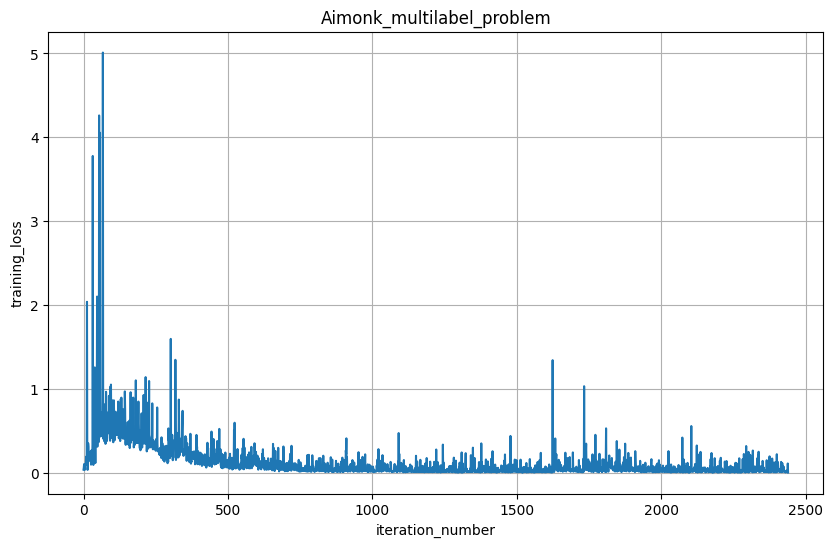

In [ ]:
import matplotlib.pyplot as plt


iteration_losses = []
num_epochs = 20
model.train()

print("🚀 Starting Training... this may take a few minutes.")

for epoch in range(num_epochs):
    running_loss = 0.0

    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)


        loss.backward()
        optimizer.step()


        iteration_losses.append(loss.item())
        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs} - Average Loss: {running_loss/len(train_loader):.4f}")


torch.save(model.state_dict(), 'aimonk_model_weights.pth')
print("✅ Model weights saved as 'aimonk_model_weights.pth'")
plt.figure(figsize=(10, 6))
plt.plot(iteration_losses)


plt.title("Aimonk_multilabel_problem")
plt.xlabel("iteration_number")
plt.ylabel("training_loss")

plt.grid(True)
plt.show()

In [49]:
def predict_image(image_path):

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])


    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)


    model.eval()
    with torch.no_grad():
        output = model(img_tensor)

        probabilities = torch.sigmoid(output).cpu().numpy()[0]

    attr_names = ['Attr1', 'Attr2', 'Attr3', 'Attr4']
    found = []

    print(f"--- Results for {os.path.basename(image_path)} ---")
    for i in range(4):
        if probabilities[i] > 0.5:
            found.append(attr_names[i])
            print(f"✅ {attr_names[i]}: Present ({probabilities[i]:.2f})")
        else:
            print(f"❌ {attr_names[i]}: Absent ({probabilities[i]:.2f})")

    print(f"\nFinal List of Attributes: {found}")


test_img = '/content/drive/MyDrive/Multilabel/images/image_10.jpg'
predict_image(test_img)

--- Results for image_10.jpg ---
❌ Attr1: Absent (0.50)
✅ Attr2: Present (0.52)
❌ Attr3: Absent (0.48)
❌ Attr4: Absent (0.29)

Final List of Attributes: ['Attr2']
